### STA 4724: Homework 3 - Due Friday, Oct. 18 
**Instructions**: Finsih the assign by directly answering the question or finishing the code in this Jupyter notebook. 

After you finish, submit the saved notebook to webcourses.

**Your name:**   Gino Benitez                  

**Your ID:** 5110519

## Question 1: kNN
For the *yeast* dataset, we want to predicte the compartment in a cell that a yeast protein will localize to based on properties of its sequence.

**(a)** Read the training and testing datasets.

In [2]:
import pandas as pd
yeast_train = pd.read_csv('yeast_train.csv')
yeast_test = pd.read_csv('yeast_test.csv')
yeast_train

,id,f0,f1,f2,f3,f4,f5,f6,f7,class
0,1,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,2,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,3,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,4,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,5,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT
...,...,...,...,...,...,...,...,...,...,...
1034,1035,0.38,0.40,0.66,0.35,0.5,0.0,0.43,0.11,CYT
1035,1036,0.81,0.62,0.43,0.17,0.5,0.0,0.53,0.22,ME2
1036,1037,0.47,0.43,0.61,0.40,0.5,0.0,0.48,0.47,NUC
1037,1038,0.43,0.40,0.60,0.16,0.5,0.0,0.53,0.39,NUC


**(b)** Use leave-one-out cross validation to select the value of $k$ for kNN model.

Hint 1: try to apply kNN with a fixed $k$ first, then figure out how to use cross validation. In *yeast_3.txt*, I list the result when $k=3$ and you can use it as a reference.

Hint 2: Some of the $k$ values are not suitable to be the "best". You shouldn't even test them in the cross validation.

In [ ]:
k = 3
from sklearn import neighbors 
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import cross_val_score, LeaveOneOut
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
# Separate features (X) and target (y) from training data
# Remove 'id' column and use only feature columns f0-f7
X_train = yeast_train.drop(['id', 'class'], axis=1)  
y_train = yeast_train['class']  

X_test = yeast_test.drop(['id', 'class'], axis=1)  
y_test= yeast_test['class'] 

# kNN classifier
nbrs = neighbors.KNeighborsClassifier(k)
nbrs.fit(X_train, y_train)
predictions = nbrs.predict(X_test)
predictions

k_values = range(1, 21, 2)
cv_scores = []
loo = LeaveOneOut()
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=loo)
    mean_score = scores.mean()
    cv_scores.append(mean_score)
best_k_cv = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)
best_k_cv

15

**(c)** Train the kNN model with the best $k$, and use it to predicte the testing data.

In [4]:
nbrs = neighbors.KNeighborsClassifier(n_neighbors=best_k_cv)
nbrs.fit(X_train, y_train)
predictions = nbrs.predict(X_test)
predictions
final_accuracy = accuracy_score(y_test, predictions)
final_accuracy

0.5842696629213483

**(d)** Print the confusion matrix, then manually compute the accuracy based on the confusion matrix. That is, don't call any built-in function for the accuracy, but type the equation you will use for calculating the accuracy.

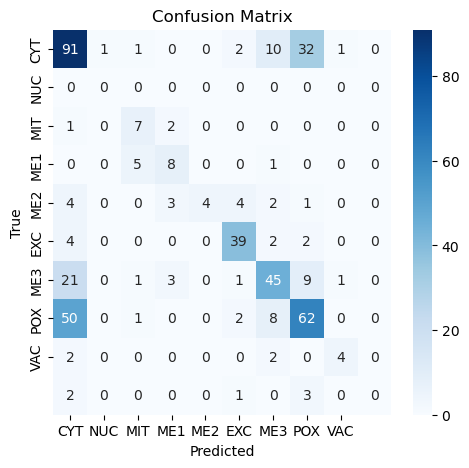

In [5]:
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=yeast_test['class'].unique(), yticklabels=yeast_test['class'].unique())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Question 2: Logistic Regression

We study the *myopia* dataset in this problem.

**(a)** Read the data file and make a scatterplot of MYOPIA vs. SPHEQ.

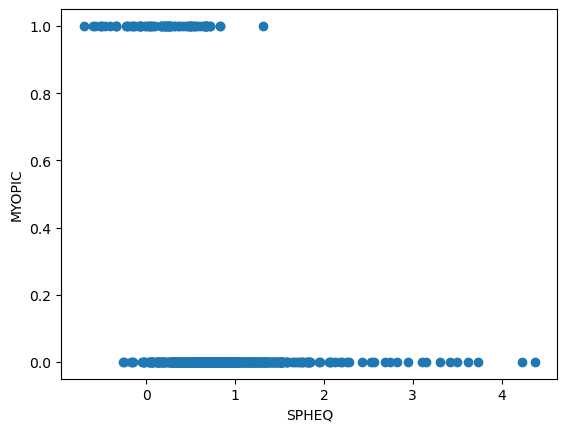

In [8]:

myopia = pd.read_csv('myopia.csv')
myopia
plt.scatter(myopia['SPHEQ'], myopia['MYOPIC'])
plt.xlabel('SPHEQ')
plt.ylabel('MYOPIC')
plt.show()


**(b)** Fit the logistic regression model of SPHEQ on MYOPIA

In [ ]:
from sklearn.linear_model import LogisticRegression
X = myopia[['SPHEQ']]
y = myopia['MYOPIC']

log_reg = LogisticRegression()
log_reg.fit(X, y)



LogisticRegression()

**(c)** Plot the logistic function found in (b) together with the scatterplot. You are looking for something like 

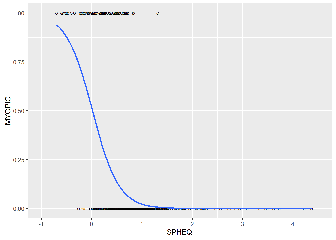

Hint: Although we didn't make this logistic function plot in class, the idea behind it is similar to the linear function plot in the earlier lecture. 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


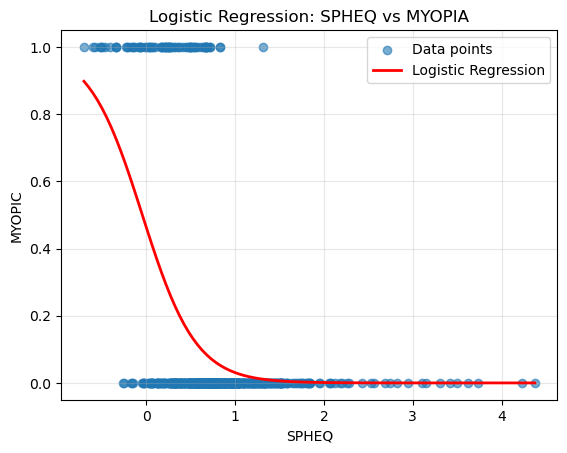

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a range of SPHEQ values for smooth curve
spheq_range = np.linspace(myopia['SPHEQ'].min(), myopia['SPHEQ'].max(), 100)
spheq_range = spheq_range.reshape(-1, 1)

# Get predictions from the logistic regression model
probabilities = log_reg.predict_proba(spheq_range)[:, 1]

plt.scatter(myopia['SPHEQ'], myopia['MYOPIC'], alpha=0.6, label='Data points')

# Plot logistic curve
plt.plot(spheq_range.flatten(), probabilities, 'r-', linewidth=2, label='Logistic Regression')

# Add labels and legend
plt.xlabel('SPHEQ')
plt.ylabel('MYOPIC')
plt.title('Logistic Regression: SPHEQ vs MYOPIA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Question 3: Naive Bayes
We have the *vote* datasets collected from 1984 United States Congressional Voting Records.

**(a)** Read the training and testing data file, and make any necessary preprocess so the data is ready to be used by naive bayes.

Hint: computer cannot read 'y/n' just like it cannot read tweets directly.

In [29]:
train_df = pd.read_csv('vote_train.csv', quotechar="'")
test_df = pd.read_csv('vote_test.csv', quotechar="'")

def preprocess_data(df):
    for col in df.columns:
        if col not in ['class', 'id']:
            df[col] = df[col].map({'y': 1, 'n': 0})
    return df

process_train = preprocess_data(train_df)
process_test = preprocess_data(test_df)
X_train = process_train.drop(['id', 'class'], axis=1)
y_train = process_train['class']
X_test = process_test.drop(['id', 'class'], axis=1)
y_test = process_test['class']
X_train


,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,0,1,0,1,1,1,0,0,0,1,0,1,1,1,0,1
1,0,1,0,1,1,1,0,0,0,0,0,1,1,1,0,0
2,0,1,1,0,1,1,0,0,0,0,1,0,1,1,0,0
3,0,1,1,0,0,1,0,0,0,0,1,0,1,0,0,1
4,1,1,1,0,1,1,0,0,0,0,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,0,1,0,1,1,1,0,0,0,0,0,1,1,1,0,1
375,0,1,0,1,1,1,0,0,0,0,1,1,0,1,0,0
376,1,0,1,0,0,0,1,1,1,0,1,0,0,0,1,1
377,0,1,0,1,1,1,0,0,0,0,0,0,1,0,0,0


**(b)** Train the bayes model and use it to predict the voting result on the testing data.

In [31]:

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report


# Create and fit the Gaussian Naive Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

accuracy =accuracy_score(y_test, gnb.predict(X_test))

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    democrat       0.94      0.89      0.91        35
  republican       0.83      0.90      0.86        21

    accuracy                           0.89        56
   macro avg       0.88      0.90      0.89        56
weighted avg       0.90      0.89      0.89        56



**(c)** Plot the ROC curve and report AUC.

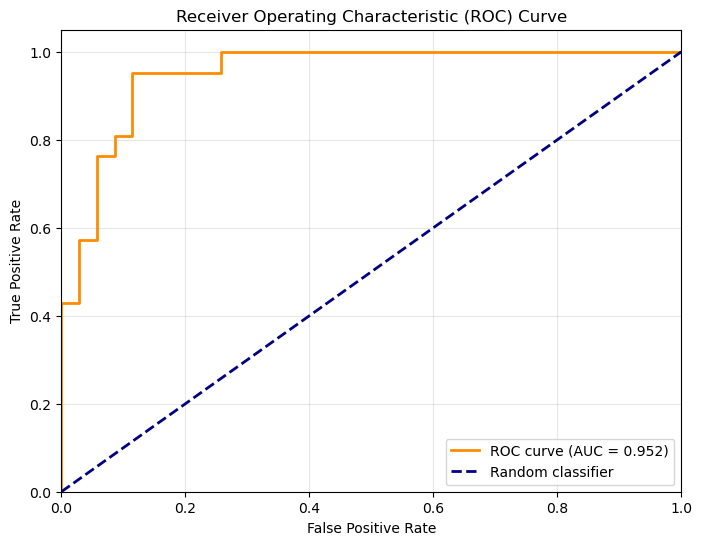

AUC Score: 0.952


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'republican' is positive class (1) and 'democrat' is negative class (0)
y_test_binary = np.where(y_test == 'republican', 1, 0)

# Get prediction probabilities for the positive class (republican)
y_proba = gnb.predict_proba(X_test)[:, 1] 

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_binary, y_proba)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.3f}")

**(d, Extra question, No bonus point)** Based on the data in the traning set, what's the most significant character for the republican voters? Can you write a short program to find it out? 

Hint: We didn't cover this in class.

**Answer:** 